<a href="https://colab.research.google.com/github/s4tlaw/KTH_AH2179/blob/main/AH2179_ASM3_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libaray Import

In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
from matplotlib import gridspec
from matplotlib.patches import Patch
from matplotlib import colors

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import calinski_harabasz_score, silhouette_score, davies_bouldin_score

# Data & Pre-process

In [2]:
url = '/content/dataset_exercise_5_clustering_highway_traffic (1).csv'
data_df = pd.read_csv(url, sep=";")
data_df.sort_values(["Date", "Interval_5"])

days = np.unique(data_df[['Date']].values.ravel())
ndays = len(days)
day_subsets_df = data_df.groupby(["Date"])

nintvals = 288
x_axis_hours = np.arange(nintvals) * (24 / nintvals)

vectorized_day_dataset = np.zeros((ndays, nintvals))
vectorized_day_dataset.fill(np.nan)

for i in range(0, ndays):
    df_t = day_subsets_df.get_group(days[i])
    for j in range(len(df_t)):
        df_t = day_subsets_df.get_group(days[i])
        vectorized_day_dataset[i, df_t.iloc[j]["Interval_5"]] = df_t.iloc[j]["flow"]

nans_per_day = np.sum(np.isnan(vectorized_day_dataset), 1)
print('number of days with missing value', np.size(np.where(nans_per_day > 0), 1))

vectorized_day_dataset_no_nans = vectorized_day_dataset[np.where(nans_per_day == 0)[0], :]
days_not_nans = days[np.where(nans_per_day == 0)[0]]

cluster_counts = [3, 5, 7]
eps_options = [300, 500, 800]


/tmp/ipykernel_6162/3926110071.py:16: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_t = day_subsets_df.get_group(days[i])
/tmp/ipykernel_6162/3926110071.py:18: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_t = day_subsets_df.get_group(days[i])


number of days with missing value 28


# Helper function

In [3]:
def remap_labels_contiguous(labels):
    labels = np.asarray(labels)
    remapped = labels.copy()
    unique_valid = sorted(np.unique(labels[labels != -1])) if -1 in labels else sorted(np.unique(labels))
    mapping = {old: new for new, old in enumerate(unique_valid)}
    for old, new in mapping.items():
        remapped[labels == old] = new
    return remapped


def assign_colors(n_clusters, days, assigments):
    assigments = np.asarray(assigments)
    days_colors = []
    color_to_cluster = []
    style_to_cluster = []
    weekend_colors = ['#67001f', '#d6604d', '#fdae61', '#f46d43', '#d53e4f', '#9e0142', '#f768a1', '#f1c232']
    mixed_colors = ['#4d4d4d', '#35978f', '#bababa', '#878787']
    weekday_colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#cab2d6', '#6a3d9a', '#b15928', '#8dd3c7',
                       '#bebada', '#fb8072', '#b3de69', '#bc80bd', '#fccde5', '#ccebc5', '#35978f', '#80cdc1']

    cluster_id_weekdays_share = [0] * n_clusters
    cluster_id_weekend_share = [0] * n_clusters
    cluster_id_all_days = [0] * n_clusters
    for i in range(n_clusters):
        color_to_cluster.append(None)
        style_to_cluster.append(None)

    for i in range(len(days)):
        if assigments[i] != -1:
            cluster_id_all_days[assigments[i]] += 1
            pomT = datetime.datetime.strptime(str(days[i]), '%Y-%m-%d') if '-' in str(days[i]) \
                else datetime.datetime.strptime(str(days[i]), '%Y%m%d')
            if int(pomT.weekday()) < 5:
                cluster_id_weekdays_share[assigments[i]] += 1
            else:
                cluster_id_weekend_share[assigments[i]] += 1

    print('cluster_id_weekdays_share', cluster_id_weekdays_share)
    print('cluster_id_weekend_share', cluster_id_weekend_share)

    for i in range(len(days)):
        if assigments[i] != -1:
            cluster_idx = assigments[i]
            if color_to_cluster[assigments[i]] is None:
                if cluster_id_weekend_share[cluster_idx] / float(cluster_id_all_days[cluster_idx]) > 0.6:
                    color_to_cluster[assigments[i]] = weekend_colors.pop()
                    style_to_cluster[assigments[i]] = ':'
                elif cluster_id_weekdays_share[cluster_idx] / float(cluster_id_all_days[cluster_idx]) > 0.6:
                    color_to_cluster[assigments[i]] = weekday_colors.pop(0)
                    style_to_cluster[assigments[i]] = '-'
                else:
                    color_to_cluster[assigments[i]] = mixed_colors.pop()
                    style_to_cluster[assigments[i]] = ':'
            days_colors.append(color_to_cluster[assigments[i]])
        else:
            days_colors.append(None)

    return days_colors, color_to_cluster, style_to_cluster


def calmap(ax, year, data, days, assigments, n_clusters, days_colors, color_to_cluster, limit_graphics=False):
    ax.tick_params('x', length=0, labelsize="medium", which='major')
    ax.tick_params('y', length=0, labelsize="x-small", which='major')

    xticks, labels = [], []
    start = datetime.datetime(year, 1, 1).weekday()

    for month in range(1, 13):
        first = datetime.datetime(year, month, 1)
        last = first + relativedelta(months=1, days=-1)
        y0 = first.weekday()
        y1 = last.weekday()
        x0 = (int(first.strftime("%j")) + start - 1) // 7
        x1 = (int(last.strftime("%j")) + start - 1) // 7
        P = [(x0, y0), (x0, 7), (x1, 7), (x1, y1 + 1), (x1 + 1, y1 + 1), (x1 + 1, 0), (x0 + 1, 0), (x0 + 1, y0)]
        xticks.append(x0 + (x1 - x0 + 1) / 2)
        labels.append(first.strftime("%b"))
        ax.add_artist(Polygon(P, edgecolor="black", facecolor="None", linewidth=1, zorder=20, clip_on=False))

    ax.add_artist(Line2D([0, 53], [5, 5], linewidth=1, zorder=20, color="black", linestyle='dashed'))

    if not limit_graphics:
        ax.set_xticks(xticks)
        ax.set_xticklabels(labels)
        ax.set_yticks(0.5 + np.arange(7))
        ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
        ax.set_title("{}".format(year), weight="semibold")
    else:
        plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

    valid = datetime.datetime(year, 1, 1).weekday()
    data[:valid, 0] = np.nan
    valid = datetime.datetime(year, 12, 31).weekday()
    data[valid + 1:, x1] = np.nan

    for i in range(len(days)):
        pomT = datetime.datetime.strptime(str(days[i]), '%Y-%m-%d') if '-' in str(days[i]) \
            else datetime.datetime.strptime(str(days[i]), '%Y%m%d')
        week_number = int(pomT.strftime("%W"))
        day_of_week = int(pomT.weekday())
        data[day_of_week, week_number] = assigments[i]

    cmap = colors.ListedColormap(color_to_cluster)
    bounds = [-0.1] + [i - 0.1 + 1 for i in range(n_clusters)]
    norm = colors.BoundaryNorm(bounds, cmap.N)
    ax.imshow(data, extent=[0, 53, 0, 7], zorder=10, interpolation='nearest', origin='lower', cmap=cmap, norm=norm)

# Evaluation Metrics

In [4]:
def evaluate_clustering(X, labels):
    labels = np.asarray(labels)
    row_has_nan = np.isnan(X).any(axis=1)
    valid_mask = (labels != -1) & (~row_has_nan)

    if valid_mask.sum() < 2 or len(np.unique(labels[valid_mask])) < 2:
        return {"Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan}

    X_use = X[valid_mask]
    labels_use = labels[valid_mask]
    return {
        "Silhouette": silhouette_score(X_use, labels_use),
        "Davies-Bouldin": davies_bouldin_score(X_use, labels_use),
        "Calinski-Harabasz": calinski_harabasz_score(X_use, labels_use),
    }


def assign_to_nearest_centroid(X_eval, X_train, train_labels):
    train_labels = np.asarray(train_labels)
    valid_train_labels = np.unique(train_labels[train_labels != -1])

    if len(valid_train_labels) == 0:
        return np.full(X_eval.shape[0], -1)

    centroids = np.array([np.nanmean(X_train[train_labels == lbl], axis=0) for lbl in valid_train_labels])

    eval_labels = np.full(X_eval.shape[0], -1)
    for i in range(X_eval.shape[0]):
        row = X_eval[i]
        if np.isnan(row).any():
            continue
        dists = np.nanmean((centroids - row) ** 2, axis=1)
        if np.all(np.isnan(dists)):
            continue
        eval_labels[i] = valid_train_labels[np.nanargmin(dists)]
    return eval_labels

# Model Parameter variation helper

In [5]:
def run_kmeans_variants(X, cluster_counts, init_options=("k-means++", "random"), random_state=0):
    results = {}
    for k in cluster_counts:
        for init in init_options:
            model = KMeans(n_clusters=k, init=init, random_state=random_state, n_init="auto").fit(X)
            results[f"k={k}, init={init}"] = model.labels_
    return results


def run_agglo_variants(X, cluster_counts, linkage_options=("ward", "complete", "average")):
    results = {}
    for k in cluster_counts:
        for linkage in linkage_options:
            model = AgglomerativeClustering(n_clusters=k, metric="euclidean", linkage=linkage).fit(X)
            results[f"k={k}, linkage={linkage}"] = model.labels_
    return results


def run_dbscan_variants(X, eps_options, min_samples_options=(2, 5)):
    results = {}
    for eps in eps_options:
        for ms in min_samples_options:
            model = DBSCAN(eps=eps, min_samples=ms).fit(X)
            n_found = len(np.unique(model.labels_[model.labels_ != -1]))
            results[f"eps={eps}, min_samples={ms} (k={n_found})"] = model.labels_
    return results

# Score Chart Ploter

In [6]:
def plot_method_scores(method_name, df, save_figure=None, show_figure=True):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    metrics_internal = ["Silhouette (internal)", "Davies-Bouldin (internal)", "Calinski-Harabasz (internal)"]
    metrics_external = ["Silhouette (external)", "Davies-Bouldin (external)", "Calinski-Harabasz (external)"]

    x = np.arange(len(df))
    labels = df["variant"]

    for ax, m_int, m_ext in zip(axes, metrics_internal, metrics_external):
        ax.plot(x, df[m_int], marker='o', label="Internal", color='#1f78b4')
        ax.plot(x, df[m_ext], marker='s', linestyle='--', label="External", color='#e31a1c')
        ax.set_title(m_int.split(" (")[0], fontsize=10, weight='semibold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
        ax.legend(fontsize=8)

    fig.suptitle(f"{method_name}: Internal vs External Evaluation Across Parameters", weight='semibold')
    plt.tight_layout()
    if save_figure:
        plt.savefig(save_figure)
    if show_figure or save_figure is None:
        plt.show()


# Load external evaluation dataset

In [7]:
url2 = '/content/evaluation_dataset_exercise_5_clustering_highway_traffic.csv'
data_eval_df = pd.read_csv(url2, sep=";")
data_eval_df.sort_values(["Date", "Interval_5"], inplace=True)

days_eval = np.unique(data_eval_df[['Date']].values.ravel())
ndays_eval = len(days_eval)
day_eval_subsets_df = data_eval_df.groupby(["Date"])

vectorized_day_dataset_eval = np.zeros((ndays_eval, nintvals))
vectorized_day_dataset_eval.fill(np.nan)

for i in range(ndays_eval):
    df_t = day_eval_subsets_df.get_group(days_eval[i])
    for j in range(len(df_t)):
        vectorized_day_dataset_eval[i, df_t.iloc[j]["Interval_5"]] = df_t.iloc[j]["flow"]

eval_mask_valid = ~np.isnan(vectorized_day_dataset_eval).any(axis=1)
X_eval_clean = vectorized_day_dataset_eval[eval_mask_valid]


/tmp/ipykernel_6162/1417280441.py:13: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  df_t = day_eval_subsets_df.get_group(days_eval[i])


# Run model

In [8]:
kmeans_variants = run_kmeans_variants(vectorized_day_dataset_no_nans, cluster_counts)
agglo_variants = run_agglo_variants(vectorized_day_dataset_no_nans, cluster_counts)
dbscan_variants = run_dbscan_variants(vectorized_day_dataset_no_nans, eps_options)

clustering_grid = {
    "KMeans": kmeans_variants,
    "Agglomerative": agglo_variants,
    "DBSCAN": dbscan_variants,
}
variant_labels_per_method = {name: list(v.keys()) for name, v in clustering_grid.items()}

for variant_label, labels in dbscan_variants.items():
    n_noise = np.sum(labels == -1)
    print(f"{variant_label}: {n_noise}/{len(labels)} points are noise")


eps=300, min_samples=2 (k=0): 337/337 points are noise
eps=300, min_samples=5 (k=0): 337/337 points are noise
eps=500, min_samples=2 (k=6): 167/337 points are noise
eps=500, min_samples=5 (k=5): 182/337 points are noise
eps=800, min_samples=2 (k=2): 26/337 points are noise
eps=800, min_samples=5 (k=1): 28/337 points are noise


# Metrics compute

In [9]:
scores_by_method = {}
for method_name, variants in clustering_grid.items():
    rows = []
    for variant_label, labels in variants.items():
        internal = evaluate_clustering(vectorized_day_dataset_no_nans, labels)
        eval_labels = assign_to_nearest_centroid(X_eval_clean, vectorized_day_dataset_no_nans, labels)
        external = evaluate_clustering(X_eval_clean, eval_labels)

        rows.append({
            "variant": variant_label,
            "Silhouette (internal)": internal["Silhouette"],
            "Davies-Bouldin (internal)": internal["Davies-Bouldin"],
            "Calinski-Harabasz (internal)": internal["Calinski-Harabasz"],
            "Silhouette (external)": external["Silhouette"],
            "Davies-Bouldin (external)": external["Davies-Bouldin"],
            "Calinski-Harabasz (external)": external["Calinski-Harabasz"],
        })
    scores_by_method[method_name] = pd.DataFrame(rows)
    print(f"\\n{method_name} scores:")
    print(scores_by_method[method_name])

\nKMeans scores:
               variant  Silhouette (internal)  Davies-Bouldin (internal)  \
0  k=3, init=k-means++               0.269241                   1.358789   
1     k=3, init=random               0.269241                   1.358789   
2  k=5, init=k-means++               0.229698                   1.515830   
3     k=5, init=random               0.269049                   1.228414   
4  k=7, init=k-means++               0.241332                   1.481357   
5     k=7, init=random               0.219625                   1.551378   

   Calinski-Harabasz (internal)  Silhouette (external)  \
0                    159.134213               0.199174   
1                    159.134213               0.199174   
2                    114.694738               0.232162   
3                    123.382036               0.169787   
4                    103.050630               0.225664   
5                    102.972321               0.258692   

   Davies-Bouldin (external)  Calinski-Hara

# External evaluation - Prediction


KMeans prediction errors (historical-mean centroid method):
               variant  Mean RMSE   Mean MAE
0  k=3, init=k-means++  42.397101  30.939694
1     k=3, init=random  42.397101  30.939694
2  k=5, init=k-means++  37.938140  27.219801
3     k=5, init=random  39.108110  28.028301
4  k=7, init=k-means++  35.248238  24.974480
5     k=7, init=random  35.498641  25.466633

Agglomerative prediction errors (historical-mean centroid method):
                 variant  Mean RMSE   Mean MAE
0      k=3, linkage=ward  41.986329  30.533962
1  k=3, linkage=complete  47.623895  34.204186
2   k=3, linkage=average  55.177103  39.888581
3      k=5, linkage=ward  39.399212  28.231182
4  k=5, linkage=complete  41.016994  29.614758
5   k=5, linkage=average  55.229866  39.938519
6      k=7, linkage=ward  34.348113  24.420978
7  k=7, linkage=complete  39.266695  28.169994
8   k=7, linkage=average  47.333196  33.996337

DBSCAN prediction errors (historical-mean centroid method):
                        v

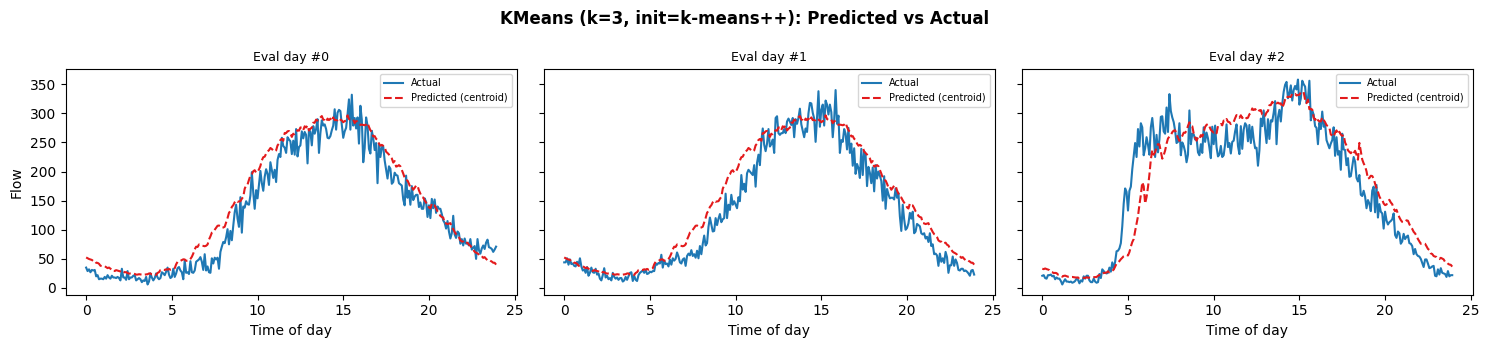

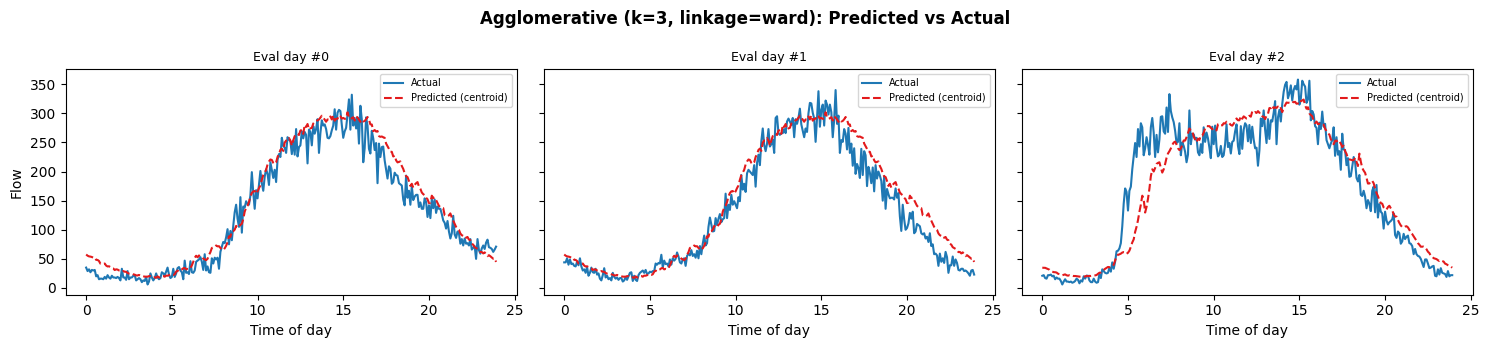

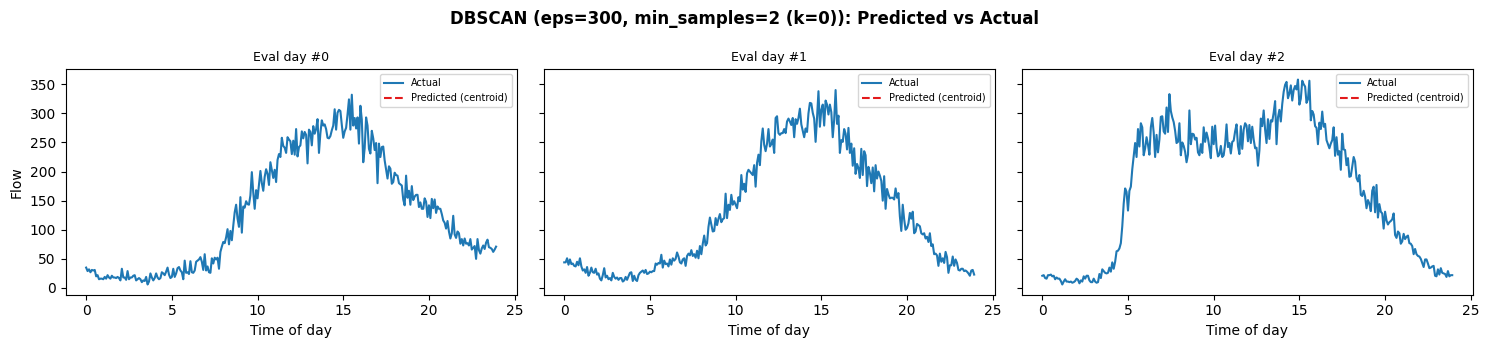

In [10]:
def predict_from_centroids(X_eval, X_train, train_labels, eval_labels):
    train_labels = np.asarray(train_labels)
    valid_train_labels = np.unique(train_labels[train_labels != -1])
    centroids = {lbl: np.nanmean(X_train[train_labels == lbl], axis=0) for lbl in valid_train_labels}

    predictions = np.full_like(X_eval, np.nan, dtype=float)
    for i in range(X_eval.shape[0]):
        lbl = eval_labels[i]
        if lbl != -1 and lbl in centroids:
            predictions[i] = centroids[lbl]
    return predictions


def compute_prediction_errors(X_actual, X_predicted):
    errors = []
    for i in range(X_actual.shape[0]):
        actual = X_actual[i]
        pred = X_predicted[i]
        mask = ~np.isnan(actual) & ~np.isnan(pred)
        if mask.sum() == 0:
            errors.append({"RMSE": np.nan, "MAE": np.nan})
            continue
        diff = actual[mask] - pred[mask]
        errors.append({"RMSE": np.sqrt(np.nanmean(diff ** 2)), "MAE": np.nanmean(np.abs(diff))})
    return pd.DataFrame(errors)


def plot_prediction_vs_actual(x_axis_hours, X_actual, X_predicted, day_indices, method_name, variant_label,
                               save_figure=None, show_figure=True):
    n = len(day_indices)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 3.5), sharey=True, squeeze=False)
    axes = axes[0]

    for ax, day_idx in zip(axes, day_indices):
        ax.plot(x_axis_hours, X_actual[day_idx], label="Actual", color='#1f78b4', linewidth=1.5)
        ax.plot(x_axis_hours, X_predicted[day_idx], label="Predicted (centroid)", color='#e31a1c',
                linestyle='--', linewidth=1.5)
        ax.set_title(f"Eval day #{day_idx}", fontsize=9)
        ax.set_xlabel("Time of day")
        ax.legend(fontsize=7)

    axes[0].set_ylabel("Flow")
    fig.suptitle(f"{method_name} ({variant_label}): Predicted vs Actual", weight='semibold')
    plt.tight_layout()
    if save_figure:
        plt.savefig(save_figure)
    if show_figure or save_figure is None:
        plt.show()


prediction_scores_by_method = {}
for method_name, variants in clustering_grid.items():
    variant_prediction_rows = []
    for variant_label, labels in variants.items():
        eval_labels = assign_to_nearest_centroid(X_eval_clean, vectorized_day_dataset_no_nans, labels)
        X_predicted = predict_from_centroids(X_eval_clean, vectorized_day_dataset_no_nans, labels, eval_labels)
        error_df = compute_prediction_errors(X_eval_clean, X_predicted)
        variant_prediction_rows.append({
            "variant": variant_label,
            "Mean RMSE": error_df["RMSE"].mean(),
            "Mean MAE": error_df["MAE"].mean(),
        })
    prediction_scores_by_method[method_name] = pd.DataFrame(variant_prediction_rows)
    print(f"\n{method_name} prediction errors (historical-mean centroid method):")
    print(prediction_scores_by_method[method_name])

example_day_indices = list(range(min(3, X_eval_clean.shape[0])))
for method_name, variants in clustering_grid.items():
    first_variant_label = list(variants.keys())[0]
    labels = variants[first_variant_label]
    eval_labels = assign_to_nearest_centroid(X_eval_clean, vectorized_day_dataset_no_nans, labels)
    X_predicted = predict_from_centroids(X_eval_clean, vectorized_day_dataset_no_nans, labels, eval_labels)
    plot_prediction_vs_actual(x_axis_hours, X_eval_clean, X_predicted, example_day_indices,
                               method_name, first_variant_label)


# Visual Matrix Grid

cluster_id_weekdays_share [94, 8, 134]
cluster_id_weekend_share [26, 75, 0]
cluster_id_weekdays_share [94, 134, 8]
cluster_id_weekend_share [26, 0, 75]
cluster_id_weekdays_share [61, 9, 85, 80, 1]
cluster_id_weekend_share [0, 76, 0, 23, 2]
cluster_id_weekdays_share [83, 2, 134, 6, 11]
cluster_id_weekend_share [0, 2, 0, 43, 56]
cluster_id_weekdays_share [39, 8, 81, 73, 1, 6, 28]
cluster_id_weekend_share [0, 57, 0, 0, 2, 42, 0]
cluster_id_weekdays_share [4, 90, 1, 54, 32, 49, 6]
cluster_id_weekend_share [52, 0, 2, 0, 5, 0, 42]
cluster_id_weekdays_share [102, 128, 6]
cluster_id_weekend_share [55, 0, 46]
cluster_id_weekdays_share [229, 1, 6]
cluster_id_weekend_share [46, 2, 53]
cluster_id_weekdays_share [234, 1, 1]
cluster_id_weekend_share [99, 2, 0]
cluster_id_weekdays_share [128, 30, 6, 71, 1]
cluster_id_weekend_share [0, 53, 46, 0, 2]
cluster_id_weekdays_share [6, 141, 86, 1, 2]
cluster_id_weekend_share [53, 0, 46, 2, 0]
cluster_id_weekdays_share [232, 1, 1, 1, 1]
cluster_id_weekend_sha

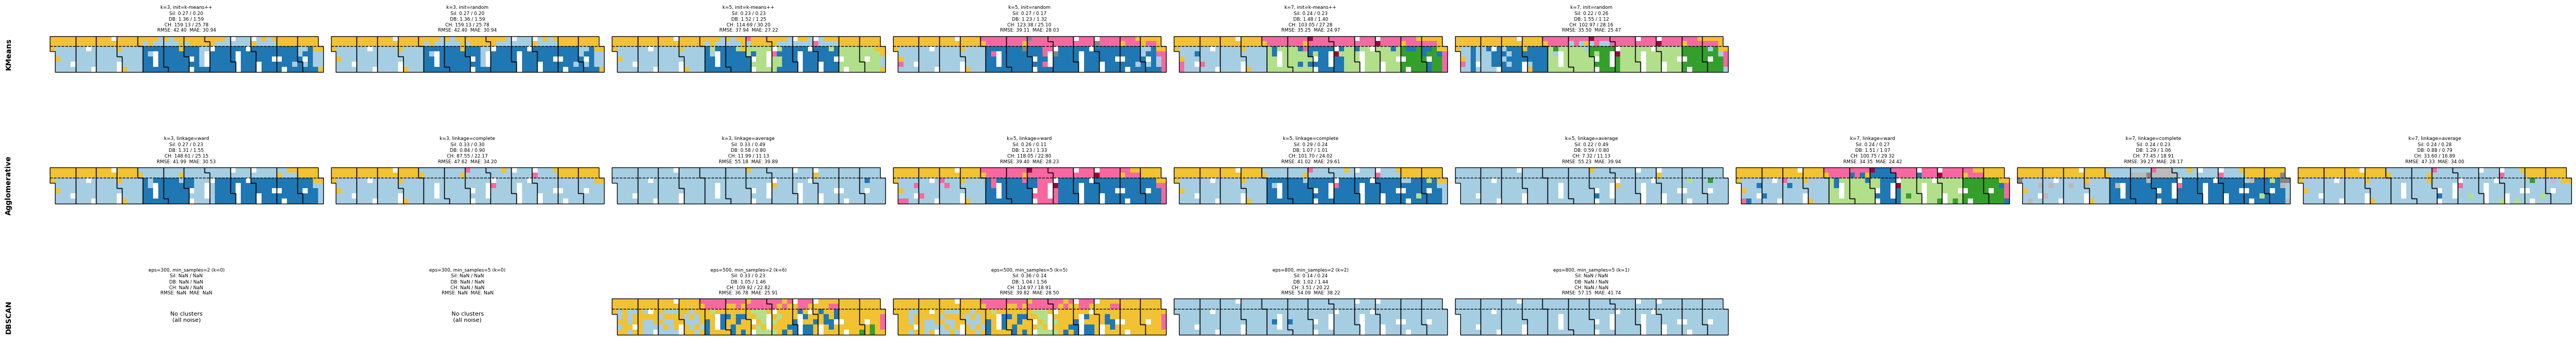

cluster_id_weekdays_share [94, 8, 134]
cluster_id_weekend_share [26, 75, 0]
cluster_id_weekdays_share [94, 134, 8]
cluster_id_weekend_share [26, 0, 75]
cluster_id_weekdays_share [61, 9, 85, 80, 1]
cluster_id_weekend_share [0, 76, 0, 23, 2]
cluster_id_weekdays_share [83, 2, 134, 6, 11]
cluster_id_weekend_share [0, 2, 0, 43, 56]
cluster_id_weekdays_share [39, 8, 81, 73, 1, 6, 28]
cluster_id_weekend_share [0, 57, 0, 0, 2, 42, 0]
cluster_id_weekdays_share [4, 90, 1, 54, 32, 49, 6]
cluster_id_weekend_share [52, 0, 2, 0, 5, 0, 42]
cluster_id_weekdays_share [102, 128, 6]
cluster_id_weekend_share [55, 0, 46]
cluster_id_weekdays_share [229, 1, 6]
cluster_id_weekend_share [46, 2, 53]
cluster_id_weekdays_share [234, 1, 1]
cluster_id_weekend_share [99, 2, 0]
cluster_id_weekdays_share [128, 30, 6, 71, 1]
cluster_id_weekend_share [0, 53, 46, 0, 2]
cluster_id_weekdays_share [6, 141, 86, 1, 2]
cluster_id_weekend_share [53, 0, 46, 2, 0]
cluster_id_weekdays_share [232, 1, 1, 1, 1]
cluster_id_weekend_sha

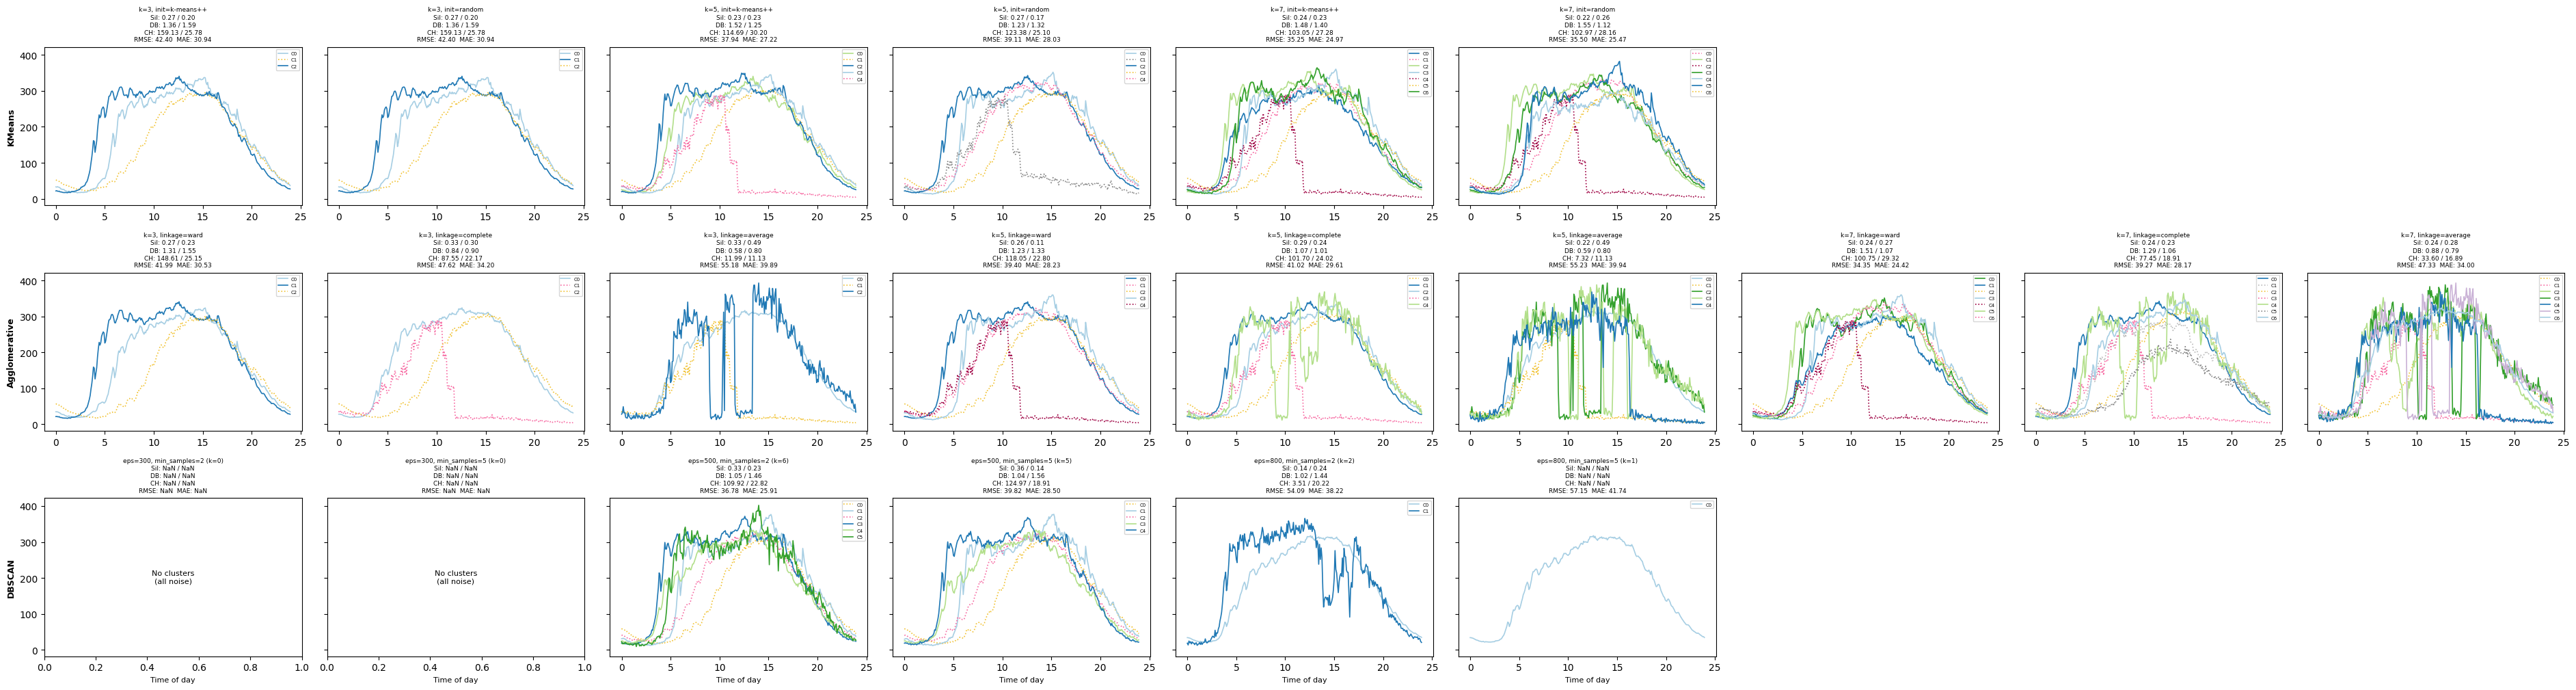

In [11]:
def build_score_lookup(scores_by_method, prediction_scores_by_method=None):
    lookup = {}
    for method_name, df in scores_by_method.items():
        lookup[method_name] = {}
        for _, row in df.iterrows():
            lookup[method_name][row["variant"]] = {
                "Sil (int)": row["Silhouette (internal)"],
                "DB (int)": row["Davies-Bouldin (internal)"],
                "CH (int)": row["Calinski-Harabasz (internal)"],
                "Sil (ext)": row["Silhouette (external)"],
                "DB (ext)": row["Davies-Bouldin (external)"],
                "CH (ext)": row["Calinski-Harabasz (external)"],
            }

    if prediction_scores_by_method is not None:
        for method_name, df in prediction_scores_by_method.items():
            for _, row in df.iterrows():
                if row["variant"] in lookup.get(method_name, {}):
                    lookup[method_name][row["variant"]]["RMSE"] = row["Mean RMSE"]
                    lookup[method_name][row["variant"]]["MAE"] = row["Mean MAE"]
    return lookup


def format_score_text(score_dict):
    if score_dict is None:
        return ""
    def fmt(v):
        return "NaN" if (v is None or (isinstance(v, float) and np.isnan(v))) else f"{v:.2f}"

    lines = [f"Sil: {fmt(score_dict.get('Sil (int)'))} / {fmt(score_dict.get('Sil (ext)'))}",
             f"DB: {fmt(score_dict.get('DB (int)'))} / {fmt(score_dict.get('DB (ext)'))}",
             f"CH: {fmt(score_dict.get('CH (int)'))} / {fmt(score_dict.get('CH (ext)'))}"]
    if "RMSE" in score_dict:
        lines.append(f"RMSE: {fmt(score_dict.get('RMSE'))}  MAE: {fmt(score_dict.get('MAE'))}")
    return "\n".join(lines)


def make_calendar_matrix_with_scores(days, clustering_grid, variant_labels_per_method, year, score_lookup,
                                      save_figure=None, show_figure=True, limit_graphics=True):
    methods = list(clustering_grid.keys())
    n_rows = len(methods)
    n_cols = max(len(v) for v in variant_labels_per_method.values())

    fig = plt.figure(figsize=(5.5 * n_cols, 2.6 * n_rows), dpi=100)

    for row, method_name in enumerate(methods):
        variants = variant_labels_per_method[method_name]
        for col, variant_label in enumerate(variants):
            labels = clustering_grid[method_name][variant_label]
            labels = remap_labels_contiguous(labels)
            n_clusters_t = len(np.unique(labels[labels != -1])) if -1 in labels else len(np.unique(labels))

            ax = fig.add_subplot(n_rows, n_cols, row * n_cols + col + 1,
                                  xlim=[0, 53], ylim=[0, 7], frameon=False, aspect=1)

            score_text = format_score_text(score_lookup.get(method_name, {}).get(variant_label))

            if n_clusters_t == 0:
                ax.text(0.5, 0.5, "No clusters\n(all noise)", ha='center', va='center',
                        fontsize=8, transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
            else:
                days_colors, color_to_cluster, style_to_cluster = assign_colors(n_clusters_t, days, labels)
                I = np.full((53, 7), np.nan).T
                calmap(ax, int(year), I, days, labels, n_clusters_t, days_colors, color_to_cluster, limit_graphics)

            title = f"{variant_label}"
            if score_text:
                title += "\n" + score_text
            ax.set_title(title, fontsize=6.5, linespacing=1.3)

            if col == 0:
                ax.text(-0.15, 0.5, method_name, transform=ax.transAxes, rotation=90,
                        fontsize=10, weight='semibold', ha='center', va='center')

    plt.tight_layout()
    if save_figure:
        plt.savefig(save_figure)
    if show_figure or save_figure is None:
        plt.show()


def make_centroids_matrix_with_scores(X, x_axis_hours, clustering_grid, variant_labels_per_method, score_lookup,
                                       minY=None, maxY=None, save_figure=None, show_figure=True):
    methods = list(clustering_grid.keys())
    n_rows = len(methods)
    n_cols = max(len(v) for v in variant_labels_per_method.values())

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows), sharey=True, squeeze=False)

    for row, method_name in enumerate(methods):
        variants = variant_labels_per_method[method_name]
        for col in range(n_cols):
            ax = axes[row][col]
            if col >= len(variants):
                ax.axis('off')
                continue

            variant_label = variants[col]
            labels = clustering_grid[method_name][variant_label]
            labels = remap_labels_contiguous(labels)
            n_clusters_t = len(np.unique(labels[labels != -1])) if -1 in labels else len(np.unique(labels))

            score_text = format_score_text(score_lookup.get(method_name, {}).get(variant_label))

            if n_clusters_t == 0:
                ax.text(0.5, 0.5, "No clusters\n(all noise)", ha='center', va='center',
                        fontsize=8, transform=ax.transAxes)
            else:
                days_colors, color_to_cluster, style_to_cluster = assign_colors(n_clusters_t, days_not_nans, labels)
                unique_labels = sorted(np.unique(labels[labels != -1])) if -1 in labels else sorted(np.unique(labels))

                for cluster_id in unique_labels:
                    centroid_yy = np.nanmean(X[np.where(labels == cluster_id)[0], :], 0).transpose()
                    ax.plot(x_axis_hours, centroid_yy,
                            style_to_cluster[cluster_id], color=color_to_cluster[cluster_id],
                            label=f"C{cluster_id}", linewidth=1.2)
                ax.legend(fontsize=5, loc='upper right')

            title = f"{variant_label}"
            if score_text:
                title += "\n" + score_text
            ax.set_title(title, fontsize=6.5, linespacing=1.3)

            if col == 0:
                ax.set_ylabel(method_name, fontsize=9, weight='semibold')
            if minY is not None and maxY is not None:
                ax.set_ylim([minY, maxY])

    for ax in axes[-1]:
        ax.set_xlabel('Time of day', fontsize=8)

    plt.tight_layout()
    if save_figure:
        plt.savefig(save_figure)
    if show_figure or save_figure is None:
        plt.show()


score_lookup = build_score_lookup(scores_by_method, prediction_scores_by_method)

make_calendar_matrix_with_scores(days_not_nans, clustering_grid, variant_labels_per_method, year=2021,
                                  score_lookup=score_lookup, save_figure=None)

make_centroids_matrix_with_scores(vectorized_day_dataset_no_nans, x_axis_hours, clustering_grid,
                                   variant_labels_per_method, score_lookup=score_lookup)


# Score Matrix Grid

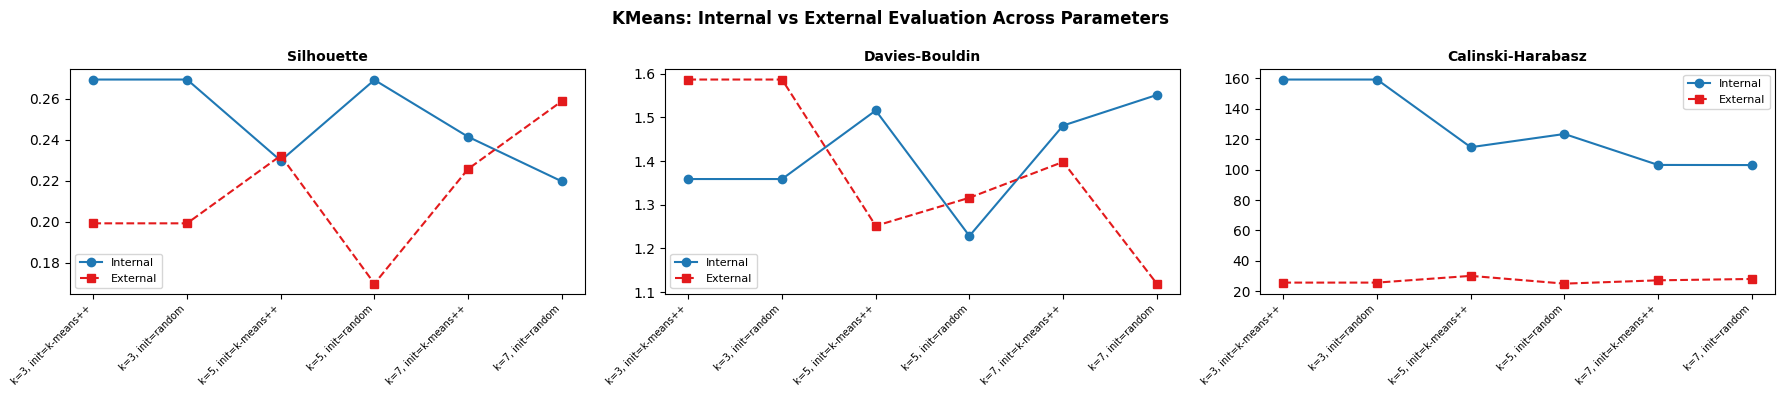

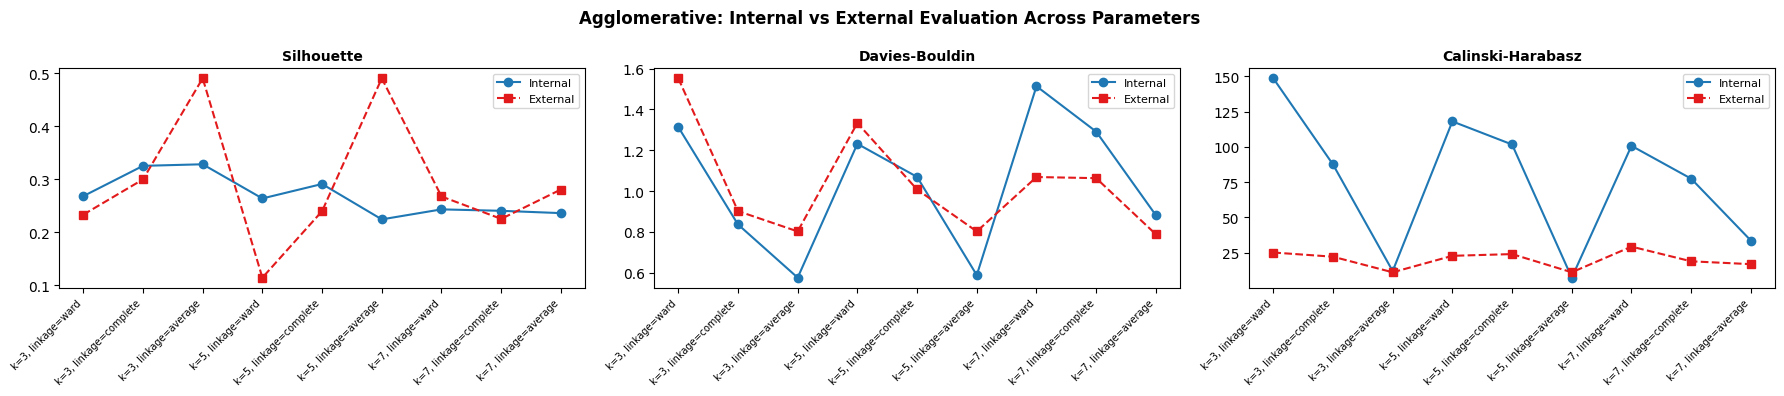

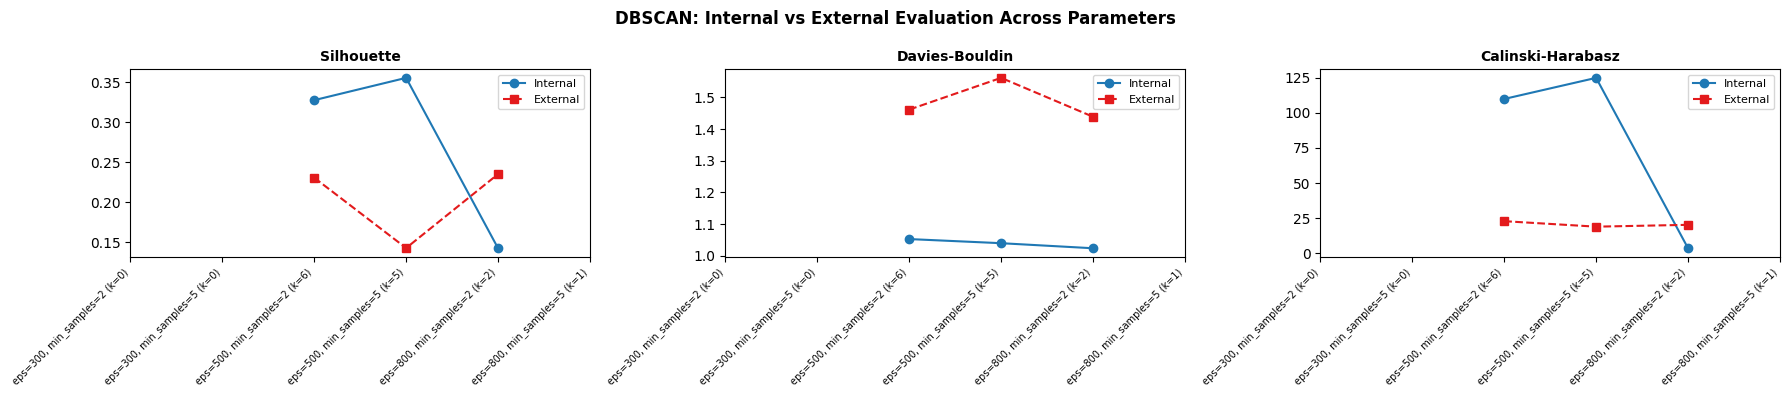

In [12]:
for method_name, df in scores_by_method.items():
    plot_method_scores(method_name, df)

# External evaluation Matrix grid

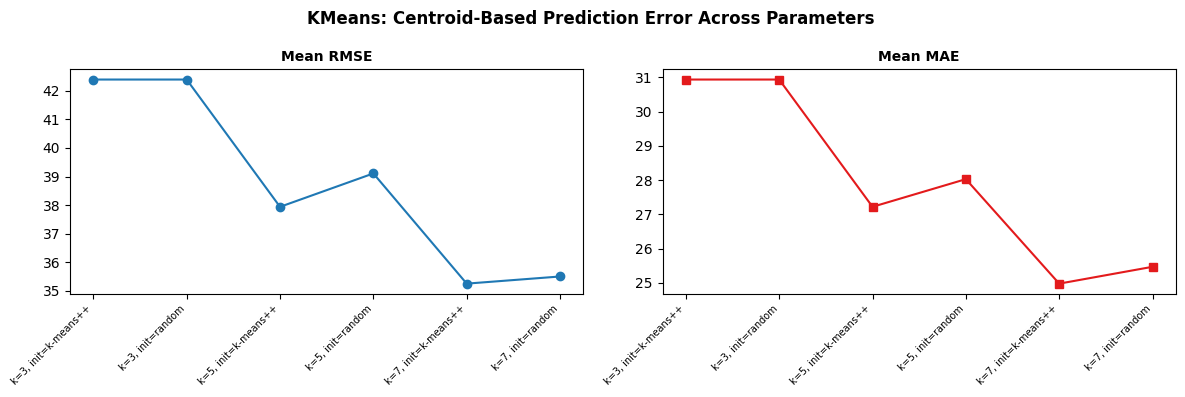

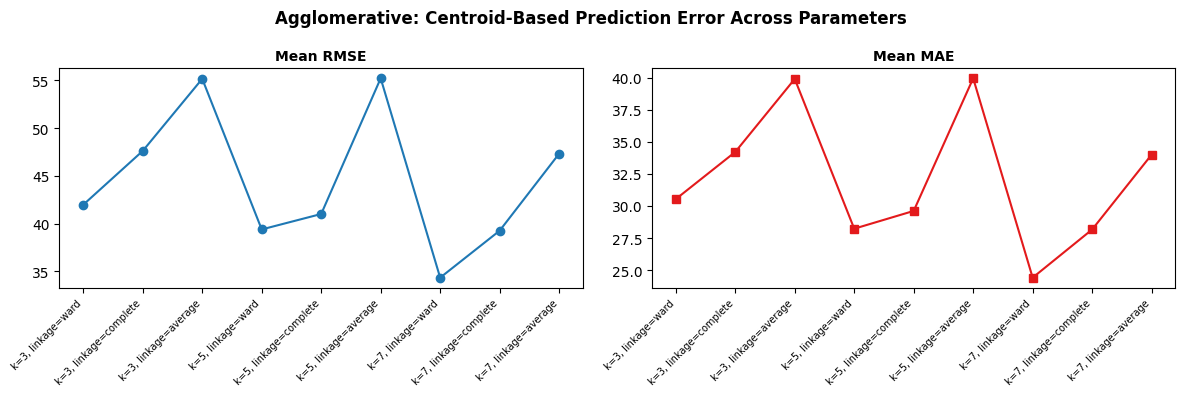

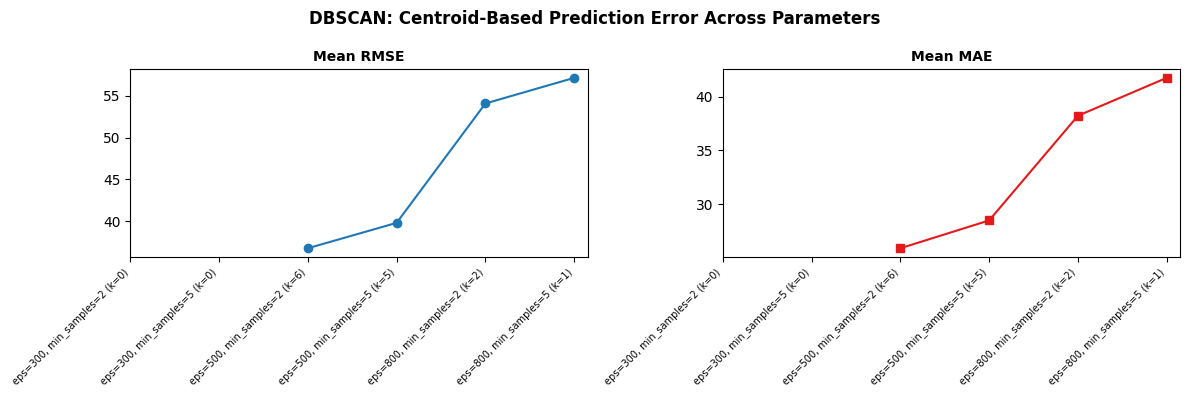

In [13]:
def plot_prediction_error_scores(method_name, df, save_figure=None, show_figure=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(df))
    labels = df["variant"]

    axes[0].plot(x, df["Mean RMSE"], marker='o', color='#1f78b4')
    axes[0].set_title("Mean RMSE", fontsize=10, weight='semibold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)

    axes[1].plot(x, df["Mean MAE"], marker='s', color='#e31a1c')
    axes[1].set_title("Mean MAE", fontsize=10, weight='semibold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)

    fig.suptitle(f"{method_name}: Centroid-Based Prediction Error Across Parameters", weight='semibold')
    plt.tight_layout()
    if save_figure:
        plt.savefig(save_figure)
    if show_figure or save_figure is None:
        plt.show()


for method_name, df in prediction_scores_by_method.items():
    plot_prediction_error_scores(method_name, df)